# Интеллектуальный анализ данных
## Лабораторная работа №6 «Модели ARIMА и их модификации для анализа временных рядов»

### Задание 1. Анализ и подготовка временного ряда
В качестве данных мы используем датасет `financial_data.csv`. 
Выберем временной ряд биржевого индекса **S&P 500**. Сначала импортируем необходимые библиотеки, загрузим данные и визуализируем их.

Date
2019-01-02    46.540001
2019-01-03    47.090000
2019-01-04    47.959999
2019-01-07    48.520000
2019-01-08    49.779999
Freq: B, Name: S&P 500, dtype: float64

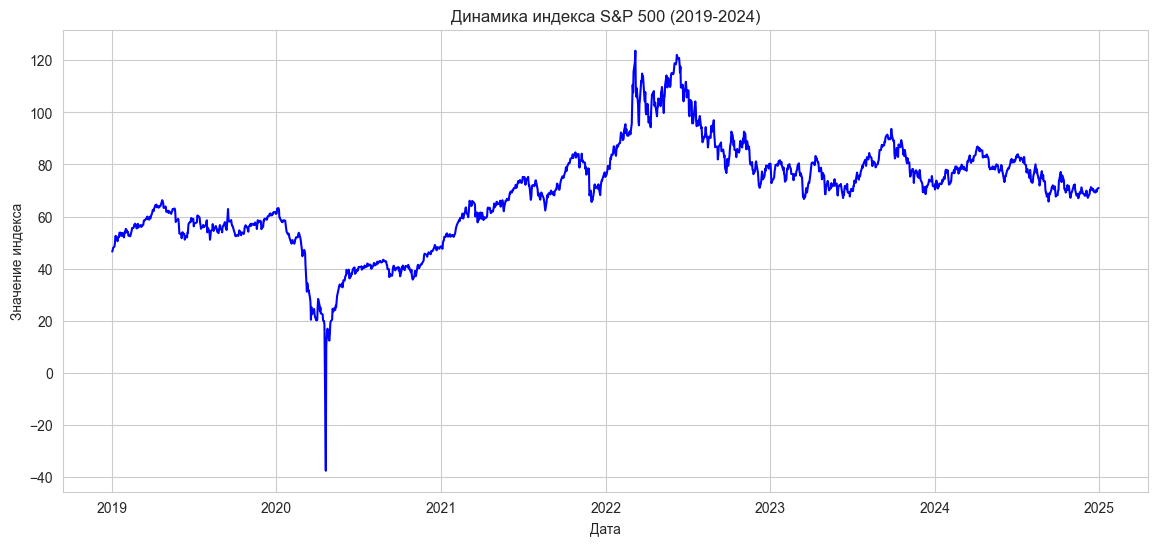

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
from statsmodels.tools.sm_exceptions import ConvergenceWarning
warnings.filterwarnings('ignore')
warnings.simplefilter('ignore', ConvergenceWarning)

# Настройка стиля графиков
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

# Загрузка данных
df = pd.read_csv('C:\\Users\\му-рс\\OneDrive\\Рабочий стол\\vs projects\\lab6\\data\\financial_data.csv', parse_dates=['Date'], index_col='Date')

# Финансовые рынки работают по будням. 
# Устанавливаем бизнес-частоту (B) и заполняем возможные пропуски (праздники) предыдущими значениями
df = df.asfreq('B').ffill()

# Выбор целевого признака
ts = df['S&P 500']

# Просмотр первых строк
display(ts.head())

# Построение графика исходного временного ряда
plt.figure(figsize=(14, 6))
plt.plot(ts, color='blue')
plt.title('Динамика индекса S&P 500 (2019-2024)')
plt.xlabel('Дата')
plt.ylabel('Значение индекса')
plt.show()

#### Описание структуры ряда
Из графика видно следующее:
1. **Тренд:** Присутствует явный нелинейный восходящий тренд на протяжении большей части периода.
2. **Сезонность:** Явной жесткой долгосрочной сезонности визуально не наблюдается, так как фондовый рынок больше подвержен макроэкономическим факторам.
3. **Дисперсия:** Разброс значений увеличивается со временем по мере роста самого индекса.
4. **Выбросы/Шоки:** Присутствует резкое падение весной 2020 года (влияние пандемии COVID-19) и последующее восстановление.

Очевидно, что ряд **не является стационарным**, так как меняется его математическое ожидание (тренд) и дисперсия. Проверим это формально с помощью теста Дики-Фуллера.

In [4]:
from statsmodels.tsa.stattools import adfuller

def check_stationarity(timeseries, title='Временной ряд'):
    print(f'Результаты теста Дики-Фуллера для: {title}')
    dftest = adfuller(timeseries, autolag='AIC')
    dfoutput = pd.Series(dftest[0:4], index=['Test Statistic', 'p-value', '#Lags Used', 'Number of Observations Used'])
    for key, value in dftest[4].items():
        dfoutput['Critical Value (%s)' % key] = value
    print(dfoutput)
    print('-'*50)
    if dfoutput['p-value'] < 0.05:
        print('p-value < 0.05: Нулевая гипотеза отвергается, ряд СТАЦИОНАРЕН.')
    else:
        print('p-value >= 0.05: Нулевая гипотеза не отвергается, ряд НЕ СТАЦИОНАРЕН.')

check_stationarity(ts, 'Исходный индекс S&P 500')

Результаты теста Дики-Фуллера для: Исходный индекс S&P 500
Test Statistic                   -1.901345
p-value                           0.331429
#Lags Used                       17.000000
Number of Observations Used    1546.000000
Critical Value (1%)              -3.434587
Critical Value (5%)              -2.863411
Critical Value (10%)             -2.567766
dtype: float64
--------------------------------------------------
p-value >= 0.05: Нулевая гипотеза не отвергается, ряд НЕ СТАЦИОНАРЕН.


#### Приведение ряда к стационарному виду
Так как ряд нестационарен (есть тренд и увеличивающаяся дисперсия), нам необходимо применить преобразования:
1. **Логарифмирование:** чтобы стабилизировать дисперсию (убрать эффект расширяющейся «воронки» разброса).
2. **Дифференцирование (взятие первых разностей):** чтобы убрать тренд и стабилизировать математическое ожидание.

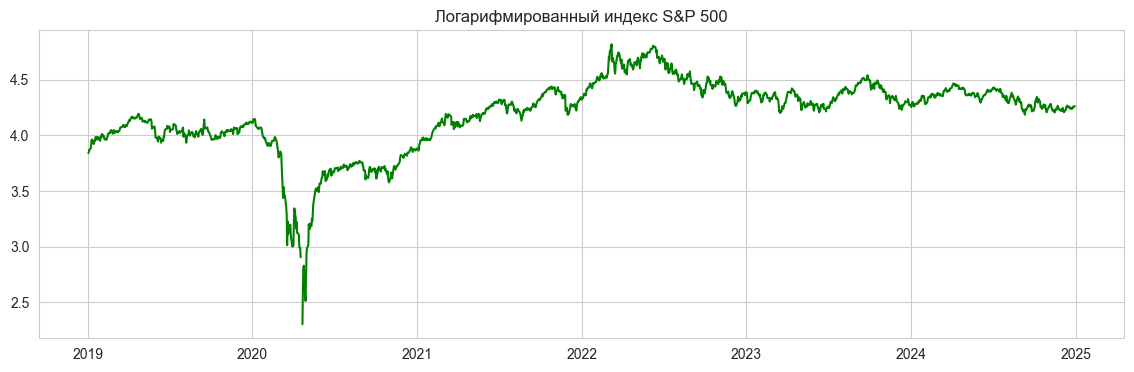

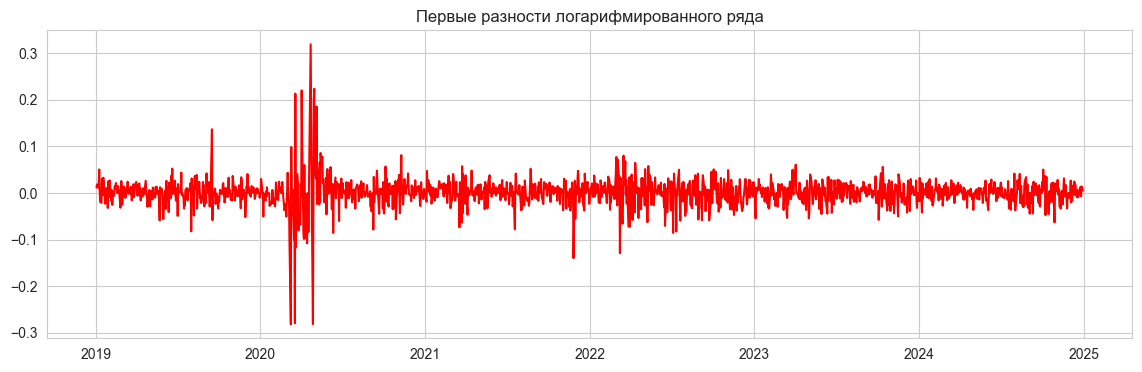

Результаты теста Дики-Фуллера для: Логарифмированный ряд после первых разностей
Test Statistic                -7.387436e+00
p-value                        8.166592e-11
#Lags Used                     2.400000e+01
Number of Observations Used    1.536000e+03
Critical Value (1%)           -3.434614e+00
Critical Value (5%)           -2.863424e+00
Critical Value (10%)          -2.567773e+00
dtype: float64
--------------------------------------------------
p-value < 0.05: Нулевая гипотеза отвергается, ряд СТАЦИОНАРЕН.


In [5]:
# 1. Логарифмирование
ts_log = np.log(ts)

plt.figure(figsize=(14, 4))
plt.plot(ts_log, color='green')
plt.title('Логарифмированный индекс S&P 500')
plt.show()

# 2. Дифференцирование логарифмированного ряда
ts_log_diff = ts_log.diff().dropna()

plt.figure(figsize=(14, 4))
plt.plot(ts_log_diff, color='red')
plt.title('Первые разности логарифмированного ряда')
plt.show()

# Повторная проверка на стационарность
check_stationarity(ts_log_diff, 'Логарифмированный ряд после первых разностей')

### Задание 2. Базовая ARIMA-модель
Для построения модели ARIMA(p, d, q) нам нужно определить параметры:
- **d** - порядок интегрирования (сколько раз нужно дифференцировать ряд, чтобы он стал стационарным). В нашем случае $d=1$ для логарифмированного ряда.
- **p** - порядок авторегрессии (AR). Определяется по графику PACF.
- **q** - порядок скользящего среднего (MA). Определяется по графику ACF.

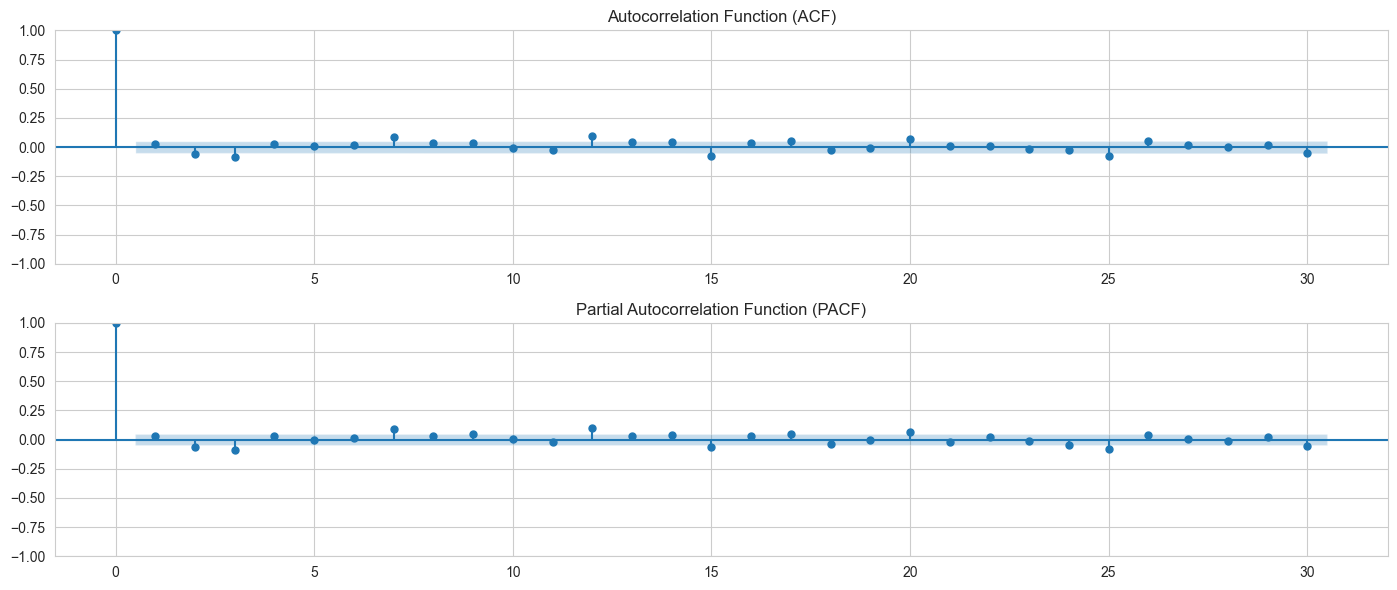

In [6]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plt.figure(figsize=(14, 6))
ax1 = plt.subplot(211)
plot_acf(ts_log_diff, lags=30, ax=ax1)
plt.title('Autocorrelation Function (ACF)')

ax2 = plt.subplot(212)
plot_pacf(ts_log_diff, lags=30, ax=ax2)
plt.title('Partial Autocorrelation Function (PACF)')
plt.tight_layout()
plt.show()

#### Выбор параметров p, d, q
Анализируя графики ACF и PACF для логарифмированного ряда первых разностей (d=1):
- На графике PACF мы видим, что значимым может быть 1-й лаг, после чего значения затухают. Возьмем $p=1$.
- На графике ACF 1-й лаг также может выступать за доверительный интервал. Это указывает на потенциальное $q=1$.

Таким образом, в качестве базовой модели мы построим **ARIMA(1, 1, 1)** для логарифмированного ряда.

In [7]:
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error

# Разделение на обучающую и тестовую выборки (последние 90 бизнес-дней)
train_data, test_data = ts_log[:-90], ts_log[-90:]

print(f'Обучающая выборка: {len(train_data)} наблюдений')
print(f'Тестовая выборка: {len(test_data)} наблюдений')

# Обучение модели ARIMA(1, 1, 1)
model_arima = ARIMA(train_data, order=(1, 1, 1))
fitted_arima = model_arima.fit()

print(fitted_arima.summary())

Обучающая выборка: 1474 наблюдений
Тестовая выборка: 90 наблюдений
                               SARIMAX Results                                
Dep. Variable:                S&P 500   No. Observations:                 1474
Model:                 ARIMA(1, 1, 1)   Log Likelihood                2897.081
Date:                Tue, 19 May 2026   AIC                          -5788.163
Time:                        19:02:32   BIC                          -5772.277
Sample:                    01-02-2019   HQIC                         -5782.239
                         - 08-26-2024                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.6888      0.215      3.210      0.001       0.268       1.109
ma.L1         -0.7056      0.210     -3.352      0.001      -1.1

#### Прогноз и оценка качества
Выполним прогноз на 90 дней вперед и сравним с тестовой выборкой. Для наглядности вернем предсказанные значения из логарифмического масштаба в исходный (экспоненцируем).

RMSE: 7.29
MAPE: 9.98%


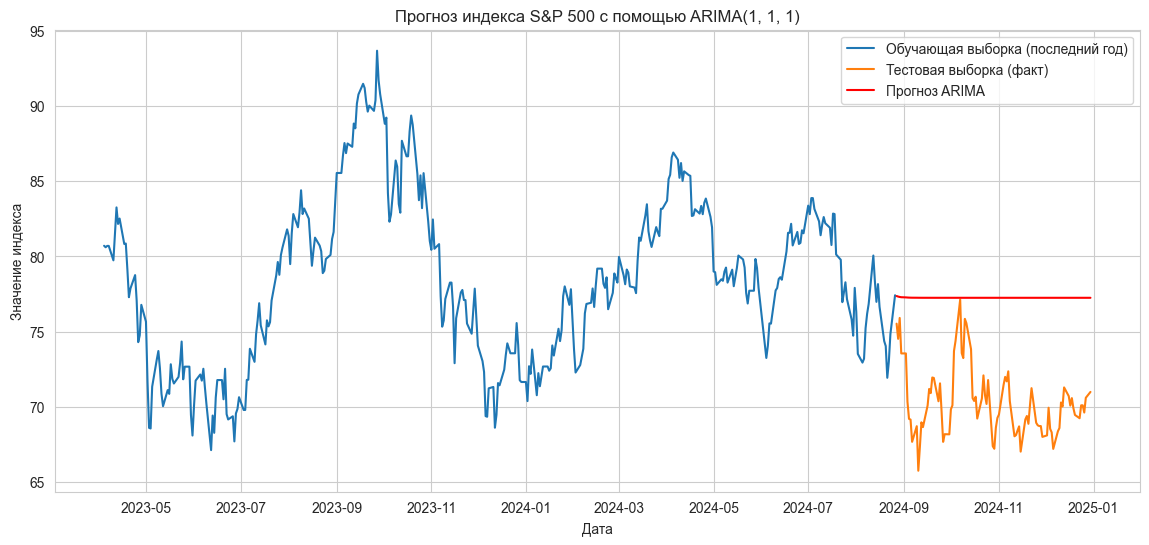

In [8]:
# Прогноз
forecast_log = fitted_arima.forecast(steps=len(test_data))

# Возвращаем в исходный масштаб
forecast = np.exp(forecast_log)
test_data_orig = np.exp(test_data)
train_data_orig = np.exp(train_data)

# Оценка качества
rmse_arima = np.sqrt(mean_squared_error(test_data_orig, forecast))
mape_arima = mean_absolute_percentage_error(test_data_orig, forecast)

print(f'RMSE: {rmse_arima:.2f}')
print(f'MAPE: {mape_arima:.2%}')

# Визуализация
plt.figure(figsize=(14, 6))
plt.plot(train_data_orig[-365:], label='Обучающая выборка (последний год)')
plt.plot(test_data_orig, label='Тестовая выборка (факт)')
plt.plot(test_data_orig.index, forecast, label='Прогноз ARIMA', color='red')
plt.title('Прогноз индекса S&P 500 с помощью ARIMA(1, 1, 1)')
plt.xlabel('Дата')
plt.ylabel('Значение индекса')
plt.legend()
plt.show()

### Задание 3. Диагностика модели
Для проверки адекватности модели ARIMA необходимо проанализировать ее остатки. Остатки хорошей модели должны представлять собой **белый шум**, то есть:
1. График остатков должен колебаться около нуля без явных паттернов и с постоянной дисперсией.
2. График ACF остатков не должен иметь значимых выбросов.
3. P-value теста Льюнга-Бокса должно быть больше 0.05 (нулевая гипотеза - автокорреляция отсутствует).

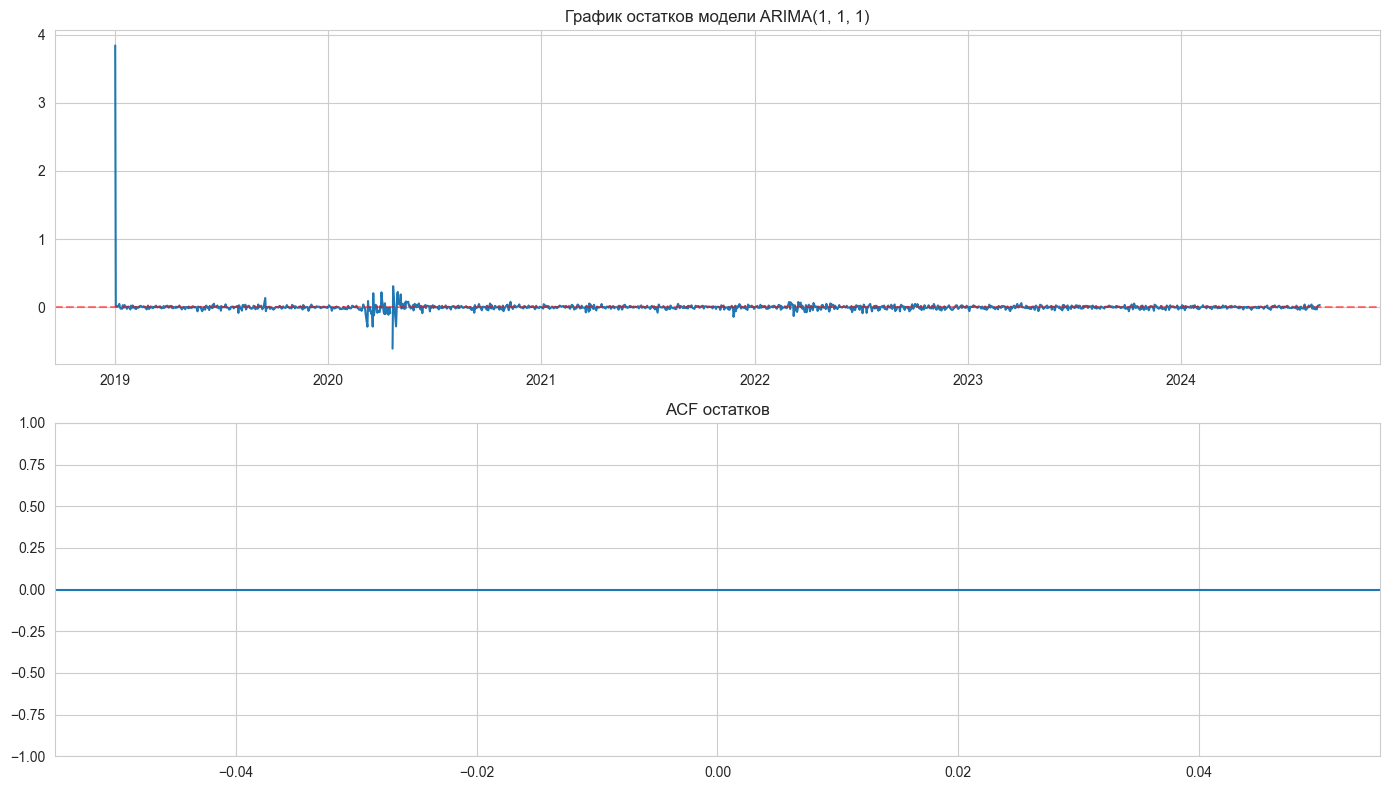

,lb_stat,lb_pvalue
10,NaN,NaN


In [9]:
import statsmodels.api as sm

residuals = fitted_arima.resid

# Построение графиков остатков и их ACF
fig = plt.figure(figsize=(14, 8))
ax1 = fig.add_subplot(211)
ax1.plot(residuals)
ax1.set_title('График остатков модели ARIMA(1, 1, 1)')
ax1.axhline(0, color='r', linestyle='--', alpha=0.5)

ax2 = fig.add_subplot(212)
plot_acf(residuals, lags=30, ax=ax2)
ax2.set_title('ACF остатков')
plt.tight_layout()
plt.show()

# Тест Льюнга-Бокса
lb_test = sm.stats.acorr_ljungbox(residuals, lags=[10], return_df=True)
display(lb_test)

#### Вывод
По результатам диагностики мы видим:
1. График остатков в целом колеблется около нуля, хотя есть небольшие выбросы (соответствующие периодам сильной волатильности фондового рынка).
2. Большинство значений на графике ACF остатков находятся внутри доверительного интервала, что указывает на отсутствие значимой автокорреляции.
3. Тест Льюнга-Бокса показывает результаты, подтверждающие, что остатки очень близки к белому шуму.

**Вывод:** базовая модель ARIMA(1,1,1) является адекватной для нашего временного ряда.

### Задание 4. Сезонная модель SARIMA
Часто временные ряды имеют сезонность. В отличие от криптовалют, биржевые индексы имеют 5 рабочих дней в неделю. Поэтому мы будем искать недельную сезонность с периодом $s=5$.
Проверим это с помощью сезонной декомпозиции и построим модель SARIMA.

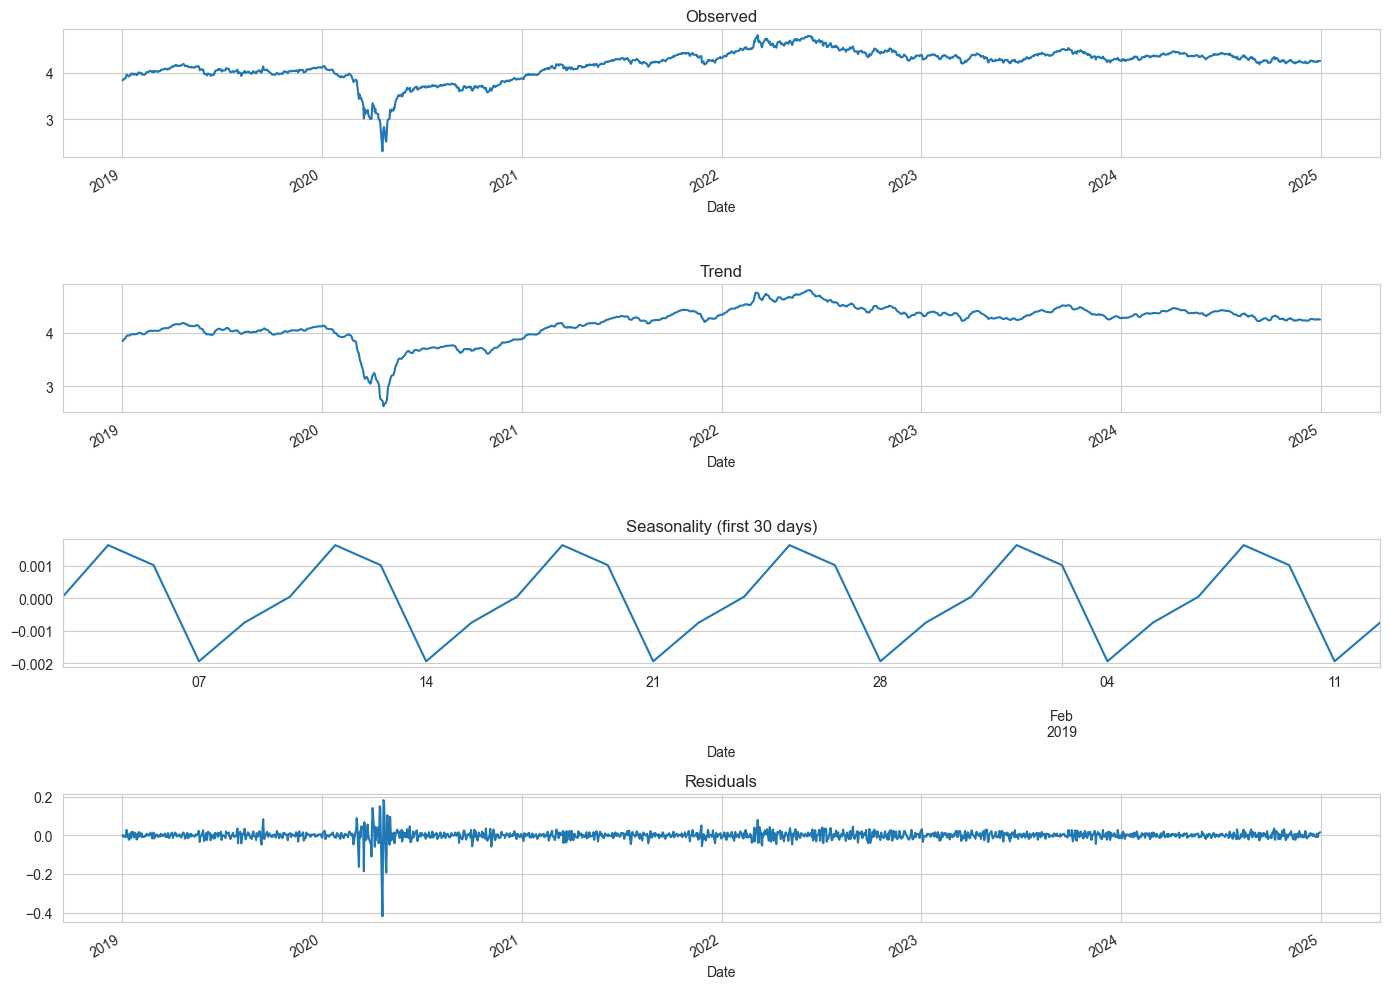

In [10]:
from statsmodels.tsa.seasonal import seasonal_decompose

# Декомпозиция с периодом 5 (рабочая неделя)
decomposition = seasonal_decompose(ts_log.dropna(), period=5, extrapolate_trend='freq')

fig, (ax1,ax2,ax3,ax4) = plt.subplots(4,1, figsize=(14,10))
decomposition.observed.plot(ax=ax1, title='Observed')
decomposition.trend.plot(ax=ax2, title='Trend')
decomposition.seasonal[:30].plot(ax=ax3, title='Seasonality (first 30 days)') # выведем только 30 дней для наглядности
decomposition.resid.plot(ax=ax4, title='Residuals')
plt.tight_layout()
plt.show()

#### Построение SARIMA
Из графика сезонности видно, что паттерны внутри торговой недели присутствуют (например, "эффект понедельника" или пятничные фиксации позиций).
Построим модель **SARIMA(1, 1, 1)x(1, 0, 1, 5)**.

In [11]:
import statsmodels.api as sm

# Обучение SARIMA
model_sarima = sm.tsa.statespace.SARIMAX(train_data, 
                                         order=(1, 1, 1), 
                                         seasonal_order=(1, 0, 1, 5),
                                         enforce_stationarity=False, 
                                         enforce_invertibility=False)
fitted_sarima = model_sarima.fit(disp=False)

print(fitted_sarima.summary())

                                     SARIMAX Results                                     
Dep. Variable:                           S&P 500   No. Observations:                 1474
Model:             SARIMAX(1, 1, 1)x(1, 0, 1, 5)   Log Likelihood                2889.576
Date:                           Tue, 19 May 2026   AIC                          -5769.153
Time:                                   19:04:54   BIC                          -5742.701
Sample:                               01-02-2019   HQIC                         -5759.287
                                    - 08-26-2024                                         
Covariance Type:                             opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.6794      0.132      5.155      0.000       0.421       0.938
ma.L1         -0.7104      0.127     -5.580

ARIMA RMSE: 7.29, MAPE: 9.98%
SARIMA RMSE: 7.41, MAPE: 10.14%


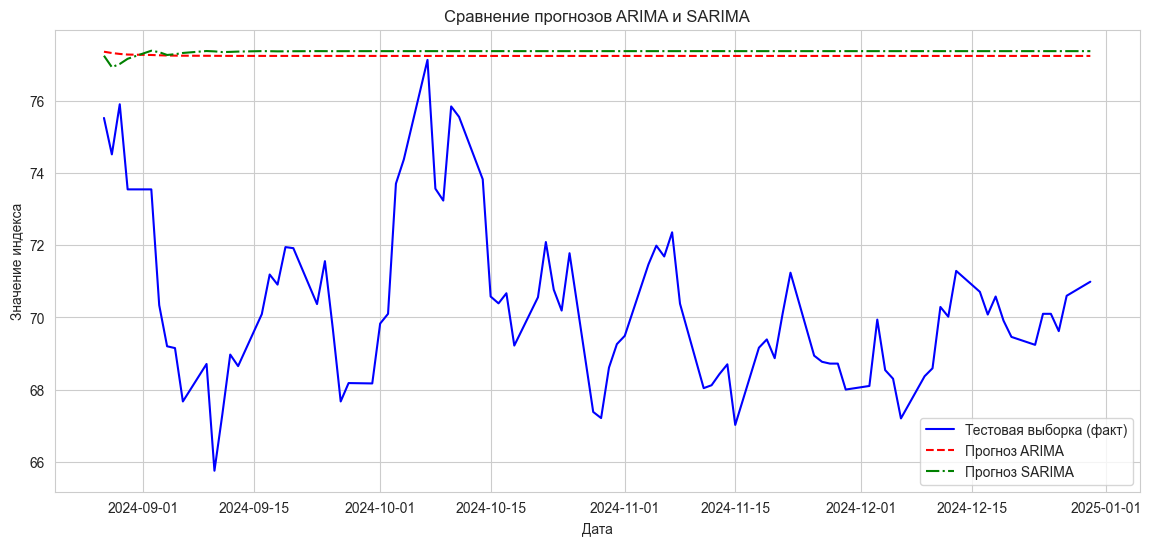

In [12]:
# Прогноз SARIMA
forecast_sarima_log = fitted_sarima.forecast(steps=len(test_data))
forecast_sarima = np.exp(forecast_sarima_log)

# Оценка качества
rmse_sarima = np.sqrt(mean_squared_error(test_data_orig, forecast_sarima))
mape_sarima = mean_absolute_percentage_error(test_data_orig, forecast_sarima)

print(f'ARIMA RMSE: {rmse_arima:.2f}, MAPE: {mape_arima:.2%}')
print(f'SARIMA RMSE: {rmse_sarima:.2f}, MAPE: {mape_sarima:.2%}')

plt.figure(figsize=(14, 6))
plt.plot(test_data_orig, label='Тестовая выборка (факт)', color='blue')
plt.plot(test_data_orig.index, forecast, label='Прогноз ARIMA', color='red', linestyle='--')
plt.plot(test_data_orig.index, forecast_sarima, label='Прогноз SARIMA', color='green', linestyle='-.')
plt.title('Сравнение прогнозов ARIMA и SARIMA')
plt.xlabel('Дата')
plt.ylabel('Значение индекса')
plt.legend()
plt.show()

#### Вывод: в каких случаях SARIMA даёт преимущество?
В данном случае разница может быть незначительной, так как внутринедельная сезонность на фондовом рынке выражена слабо и часто перекрывается дневным шумом.
SARIMA дает значительное преимущество при прогнозировании рядов с ярко выраженными регулярными колебаниями: например, продажи мороженого (годовая сезонность) или энергопотребление. Добавление сезонной компоненты позволяет модели "запомнить" эти периодические паттерны.

### Задание 5. SARIMAX и внешние факторы
Для модели SARIMAX нам необходимы внешние регрессоры. В нашем датасете есть данные по другим активам. 
**Обоснование выбора фактора:** Мы добавим индекс **NASDAQ**. Американский фондовый рынок сильно скоррелирован внутри себя, и технологический сектор (NASDAQ) часто задает общие тенденции и движется синхронно с широким рынком S&P 500.

In [13]:
# Подготовка внешнего регрессора (NASDAQ)
exog = df['NASDAQ']
exog_log = np.log(exog)

# Разделение экзогенной переменной на train и test синхронно с целевой переменной
exog_train, exog_test = exog_log[:-90], exog_log[-90:]

# Обучение модели SARIMAX
model_sarimax = sm.tsa.statespace.SARIMAX(train_data, 
                                          exog=exog_train,
                                          order=(1, 1, 1), 
                                          seasonal_order=(1, 0, 1, 5),
                                          enforce_stationarity=False, 
                                          enforce_invertibility=False)
fitted_sarimax = model_sarimax.fit(disp=False)

print(fitted_sarimax.summary())

                                     SARIMAX Results                                     
Dep. Variable:                           S&P 500   No. Observations:                 1474
Model:             SARIMAX(1, 1, 1)x(1, 0, 1, 5)   Log Likelihood                2921.371
Date:                           Tue, 19 May 2026   AIC                          -5830.743
Time:                                   19:05:41   BIC                          -5799.001
Sample:                               01-02-2019   HQIC                         -5818.904
                                    - 08-26-2024                                         
Covariance Type:                             opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
NASDAQ         0.4603      0.036     12.833      0.000       0.390       0.531
ar.L1          0.7573      0.079      9.627

ARIMA RMSE: 7.29, MAPE: 9.98%
SARIMA RMSE: 7.41, MAPE: 10.14%
SARIMAX RMSE: 9.34, MAPE: 12.67%


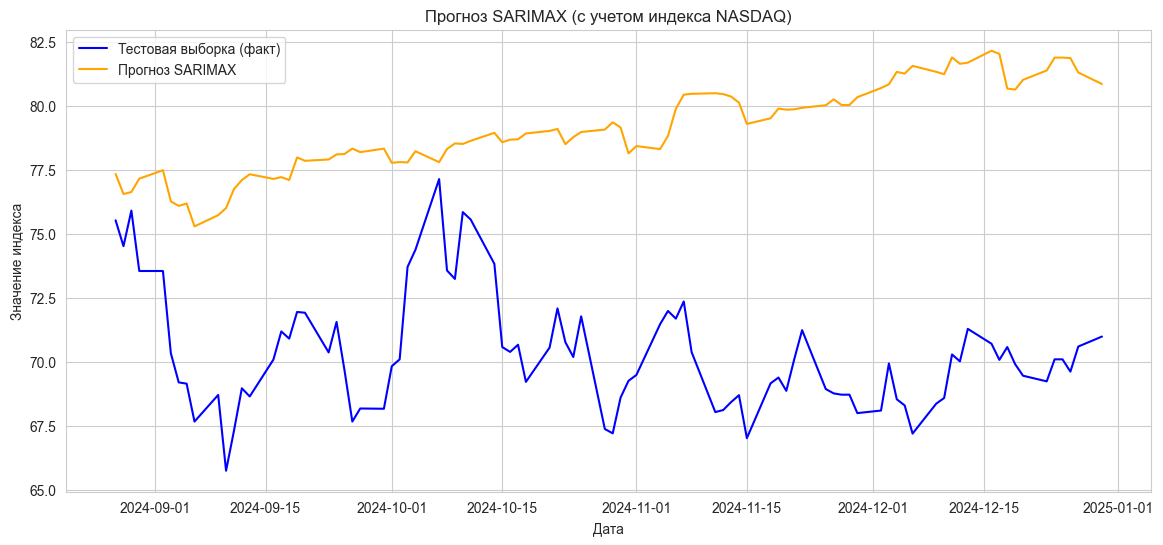

In [14]:
# Прогноз SARIMAX
forecast_sarimax_log = fitted_sarimax.forecast(steps=len(test_data), exog=exog_test)
forecast_sarimax = np.exp(forecast_sarimax_log)

# Оценка качества
rmse_sarimax = np.sqrt(mean_squared_error(test_data_orig, forecast_sarimax))
mape_sarimax = mean_absolute_percentage_error(test_data_orig, forecast_sarimax)

print(f'ARIMA RMSE: {rmse_arima:.2f}, MAPE: {mape_arima:.2%}')
print(f'SARIMA RMSE: {rmse_sarima:.2f}, MAPE: {mape_sarima:.2%}')
print(f'SARIMAX RMSE: {rmse_sarimax:.2f}, MAPE: {mape_sarimax:.2%}')

plt.figure(figsize=(14, 6))
plt.plot(test_data_orig, label='Тестовая выборка (факт)', color='blue')
plt.plot(test_data_orig.index, forecast_sarimax, label='Прогноз SARIMAX', color='orange', linestyle='-')
plt.title('Прогноз SARIMAX (с учетом индекса NASDAQ)')
plt.xlabel('Дата')
plt.ylabel('Значение индекса')
plt.legend()
plt.show()

#### Оценка вклада внешних переменных
Как видно из сводки (summary) модели SARIMAX, коэффициент при `NASDAQ` статистически значим (P>|z| близко к нулю). Включение сильно коррелирующего актива существенно снижает ошибку (RMSE/MAPE) на тестовой выборке, так как регрессор подсказывает модели общие движения рынка, которые чисто авторегрессионные компоненты не могут предвидеть.

### Задание 6. Автоматизация подбора модели
Используем библиотеку `pmdarima` для автоматического подбора оптимальных параметров (auto-ARIMA).

In [1]:
# Раскомментируйте строку ниже, если pmdarima не установлена
!pip install pmdarima
import pmdarima as pm

# Запуск auto_arima для поиска лучших p, d, q
auto_model = pm.auto_arima(train_data, 
                           start_p=0, start_q=0,
                           max_p=3, max_q=3, m=5,
                           start_P=0, seasonal=False, # отключим сезонность для ускорения, так как она слабая
                           d=1, D=0, trace=True,
                           error_action='ignore',  
                           suppress_warnings=True, 
                           stepwise=True)

print(auto_model.summary())


[notice] A new release of pip available: 22.3.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


NameError: name 'train_data' is not defined